In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set parameter y
y = 1

# Create grid points
inG_grid = np.linspace(0.0001, 0.0003, 100)
outG_grid = np.linspace(0.0001, 0.0003, 100)

# Initialize results array
results = np.zeros((len(inG_grid), len(outG_grid)))

# Calculate fee rate for each point in the grid
for i, inG in enumerate(inG_grid):
    for j, outG in enumerate(outG_grid):
        print(f"incoming fee rate: {inG}, outgoing fee rate: {outG}")
        if inG <= outG:
            results[i, j] = np.nan
        else:
            results[i, j] = (inG - outG) / (outG * (1 - inG)) * y

# Find the maximum value (ignoring NaN values)
max_value = np.nanmax(results)
print(f"Maximum fee rate value: {max_value:.4f}")

# Find the position of the maximum value
max_index = np.unravel_index(np.nanargmax(results), results.shape)
max_inG = inG_grid[max_index[0]]
max_outG = outG_grid[max_index[1]]
print(f"Maximum occurs at: inG = {max_inG:.4f}, outG = {max_outG:.4f}")

# Create the plot
plt.figure(figsize=(8, 6))

# Plot heatmap
plt.imshow(results, cmap='viridis')

# Add colorbar
plt.colorbar(label='Fee Rate')

# Add labels and title
plt.xlabel('inG')
plt.ylabel('outG')
plt.title('Fee Rate (with maximum point marked)')

# Mark the maximum point
plt.plot(max_inG, max_outG, 'r*', markersize=10, label=f'Max: {max_value:.4f}')
plt.legend()

# Invert y-axis
plt.gca().invert_yaxis()

# Set axis limits
plt.xlim(0, 1)
plt.ylim(0, 1)

# Add grid
plt.grid(True)

# Show plot
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the style
plt.style.use('seaborn')
sns.set_palette("husl")

# Create figure and axis
plt.figure(figsize=(12, 6))

# Group data by sigma
grouped = data.groupby('sigma')

# Get unique sigma values
sigma_values = sorted(data['sigma'].unique())

# Set up the x-axis positions
x = np.arange(len(sigma_values))
width = 0.35  # Width of bars

# Create the stacked bars
plt.bar(x - width/2, grouped['incoming_fee'].mean(), width, label='Incoming Fee', color='#2ecc71', alpha=0.7)
plt.bar(x - width/2, grouped['arbitrage_incoming'].mean(), width, bottom=grouped['incoming_fee'].mean(), 
        label='Incoming Arbitrage', color='#2ecc71', alpha=0.7, hatch='//')

plt.bar(x + width/2, grouped['outgoing_fee'].mean(), width, label='Outgoing Fee', color='#e74c3c', alpha=0.7)
plt.bar(x + width/2, grouped['arbitrage_outgoing'].mean(), width, bottom=grouped['outgoing_fee'].mean(), 
        label='Outgoing Arbitrage', color='#e74c3c', alpha=0.7, hatch='//')

# Customize the plot
plt.xlabel('Sigma', fontsize=12)
plt.ylabel('Profit', fontsize=12)
plt.title('Comparison of Incoming vs Outgoing Profits\n(Fee and Arbitrage Components)', fontsize=14)
plt.xticks(x, [f'{s:.2f}' for s in sigma_values], rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout to prevent label cutoff
plt.tight_layout()

plt.show()


In [ ]:
# Different ways to select columns in pandas

# 1. Select single column
print("\n1. Select single column:")
print(df['gamma'].head())

# 2. Select multiple columns using a list
print("\n2. Select multiple columns using a list:")
print(df[['gamma', 'sigma']].head())

# 3. Using dot notation (only works for column names without spaces)
print("\n3. Using dot notation:")
print(df.gamma.head())

# 4. Select columns by position using iloc
print("\n4. Select columns by position:")
print(df.iloc[:, [0, 1]].head())  # Select first two columns

# 5. Select columns by condition
print("\n5. Select columns containing 'fee' in name:")
fee_columns = [col for col in df.columns if 'fee' in col]
print(df[fee_columns].head())

# 6. Display all column names
print("\n6. All available columns:")
print(df.columns.tolist())


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


results



In [4]:
import pandas as pd

df = pd.read_csv("/Users/haofu/Desktop/AMM/Dynamic_AMM/single_step_arbitrage_profit_results_one_year.csv")

columns = ['gamma', 'sigma', 'incoming_fee', 'outgoing_fee', 'arbitrage_incoming', 'arbitrage_outgoing', 'opt_incoming_fee', 'opt_outgoing_fee', 'opt_arbitrage_incoming', 'opt_arbitrage_outgoing']

data = df[columns].copy()
data.loc[:, 'fix_incoming_fee'] = data.loc[:, 'incoming_fee'] * 1.02
data.loc[:, 'fix_outgoing_fee'] = data.loc[:, 'outgoing_fee'] * 1.02
data.loc[:, 'fix_arbitrage_incoming'] = data.loc[:, 'arbitrage_incoming'] * 1.02
data.loc[:, 'fix_arbitrage_outgoing'] = data.loc[:, 'arbitrage_outgoing'] * 1.02

data.loc[:, 'opt_total_incoming'] = data.loc[:, 'opt_incoming_fee'] + data.loc[:, 'opt_arbitrage_incoming']
data.loc[:, 'opt_total_outgoing'] = data.loc[:, 'opt_outgoing_fee'] + data.loc[:, 'opt_arbitrage_outgoing']
data.loc[:, 'opt_fee_diff'] = data.loc[:, 'opt_outgoing_fee'] - data.loc[:, 'opt_incoming_fee']
data.loc[:, 'opt_arbitrage_diff'] = data.loc[:, 'opt_arbitrage_incoming'] - data.loc[:, 'opt_arbitrage_outgoing']

print(data.head().to_markdown())



|    |   gamma |   sigma |   incoming_fee |   outgoing_fee |   arbitrage_incoming |   arbitrage_outgoing |   opt_incoming_fee |   opt_outgoing_fee |   opt_arbitrage_incoming |   opt_arbitrage_outgoing |   fix_incoming_fee |   fix_outgoing_fee |   fix_arbitrage_incoming |   fix_arbitrage_outgoing |   opt_total_incoming |   opt_total_outgoing |   opt_fee_diff |   opt_arbitrage_diff |
|---:|--------:|--------:|---------------:|---------------:|---------------------:|---------------------:|-------------------:|-------------------:|-------------------------:|-------------------------:|-------------------:|-------------------:|-------------------------:|-------------------------:|---------------------:|---------------------:|---------------:|---------------------:|
|  0 |     0.3 |     0.1 |        1.53526 |         1.5695 |             0.125916 |            0.0881411 |            985.895 |            1037.58 |                  866.467 |                  822.947 |            1.56597 |       

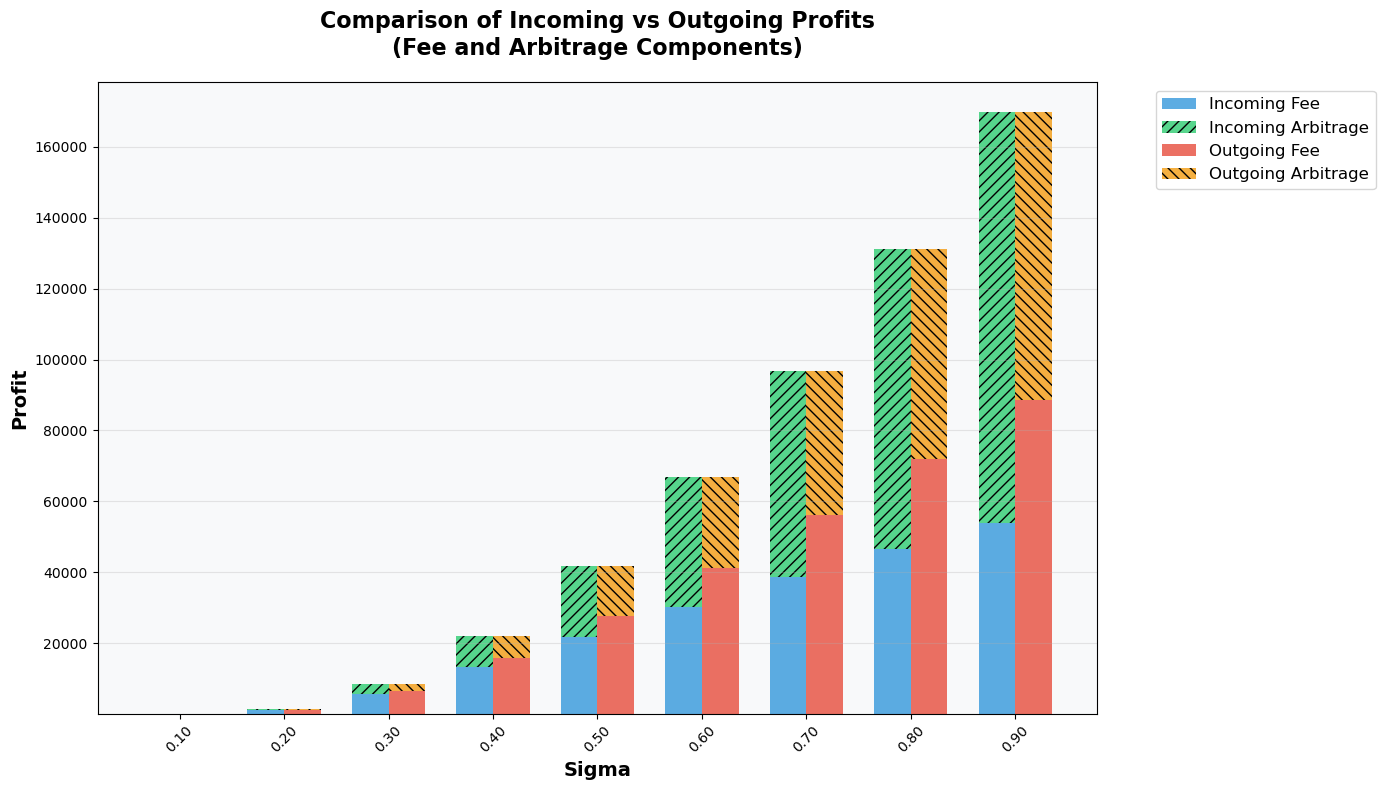

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set the style
sns.set_palette("husl")

# Create figure and axis
plt.figure(figsize=(14, 8))

# Group data by sigma and calculate means
grouped = data.groupby('sigma').agg({
    'incoming_fee': 'mean',
    'arbitrage_incoming': 'mean',
    'outgoing_fee': 'mean',
    'arbitrage_outgoing': 'mean'
}).reset_index()

# Get unique sigma values
sigma_values = sorted(data['sigma'].unique())
n_groups = len(sigma_values)

# Set up the x-axis positions
x = np.arange(n_groups)
width = 0.35  # Width of bars

# Create the grouped stacked bars
# Incoming bars (left side)
incoming_fees = grouped['incoming_fee'].values
incoming_arbitrage = grouped['arbitrage_incoming'].values

# Outgoing bars (right side)
outgoing_fees = grouped['outgoing_fee'].values
outgoing_arbitrage = grouped['arbitrage_outgoing'].values

# Plot incoming bars (stacked)
bars1_fee = plt.bar(x - width/2, incoming_fees, width, 
                   label='Incoming Fee', color='#3498db', alpha=0.8)
bars1_arb = plt.bar(x - width/2, incoming_arbitrage, width, 
                   bottom=incoming_fees, label='Incoming Arbitrage', 
                   color='#2ecc71', alpha=0.8, hatch='///')

# Plot outgoing bars (stacked)
bars2_fee = plt.bar(x + width/2, outgoing_fees, width, 
                   label='Outgoing Fee', color='#e74c3c', alpha=0.8)
bars2_arb = plt.bar(x + width/2, outgoing_arbitrage, width, 
                   bottom=outgoing_fees, label='Outgoing Arbitrage', 
                   color='#f39c12', alpha=0.8, hatch='\\\\\\')

# Add value labels on bars (optional)
def add_value_labels(bars, values, offset=0):
    for bar, value in zip(bars, values):
        height = bar.get_height() + offset
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{value:.2f}', ha='center', va='bottom', fontsize=9)

# Uncomment these lines if you want value labels on the bars
# add_value_labels(bars1_fee, incoming_fees)
# add_value_labels(bars1_arb, incoming_arbitrage, incoming_fees)
# add_value_labels(bars2_fee, outgoing_fees)
# add_value_labels(bars2_arb, outgoing_arbitrage, outgoing_fees)

# Customize the plot
plt.xlabel('Sigma', fontsize=14, fontweight='bold')
plt.ylabel('Profit', fontsize=14, fontweight='bold')
plt.title('Comparison of Incoming vs Outgoing Profits\n(Fee and Arbitrage Components)', 
          fontsize=16, fontweight='bold', pad=20)

# Set x-axis labels
plt.xticks(x, [f'{s:.2f}' for s in sigma_values], rotation=45)

# Add legend
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)

# Add grid for better readability
plt.grid(True, alpha=0.3, axis='y')

# Improve layout
plt.tight_layout()

# Optional: Add a subtle background color
plt.gca().set_facecolor('#f8f9fa')

plt.show()



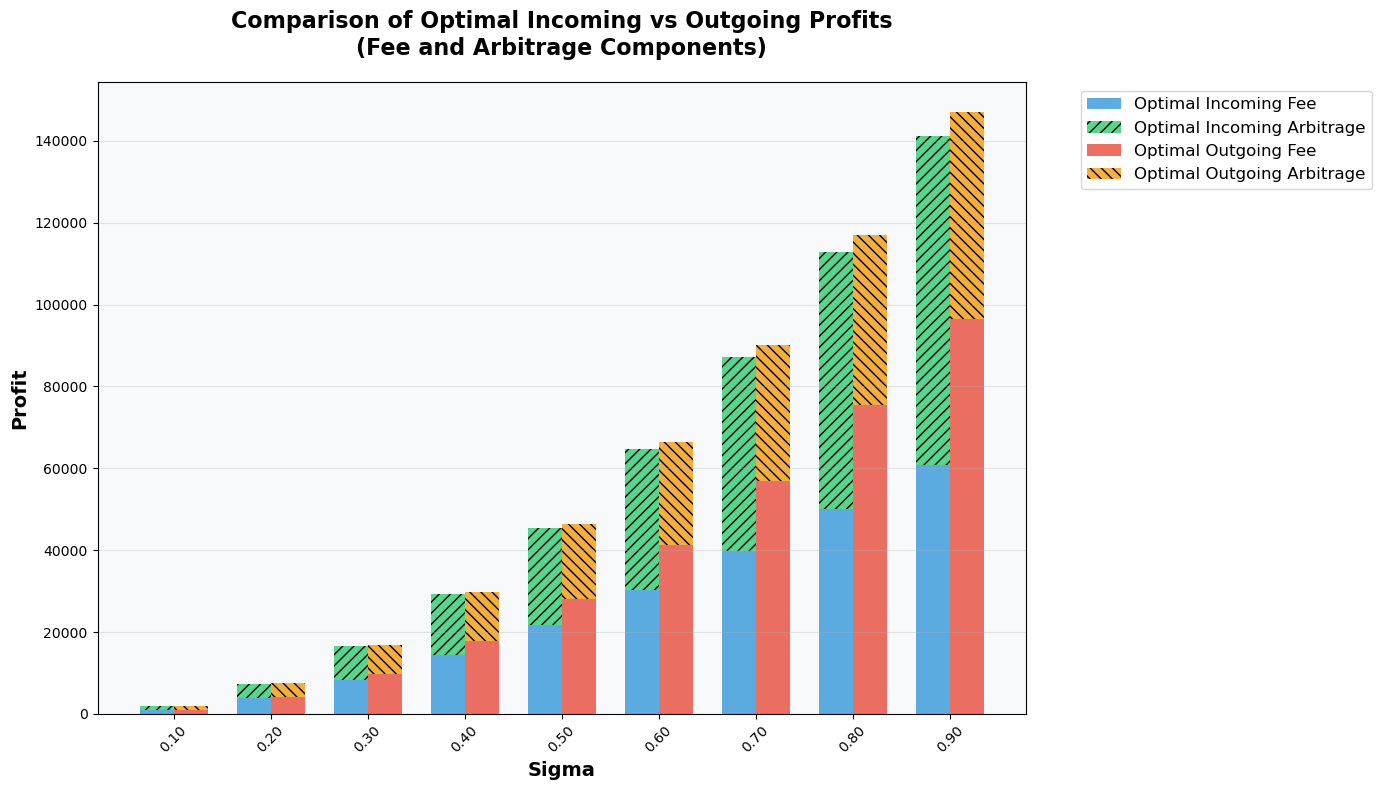

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set the style
sns.set_palette("husl")

# Create figure and axis
plt.figure(figsize=(14, 8))

# Group data by sigma and calculate means
grouped = data.groupby('sigma').agg({
    'opt_incoming_fee': 'mean',
    'opt_arbitrage_incoming': 'mean',
    'opt_outgoing_fee': 'mean',
    'opt_arbitrage_outgoing': 'mean'
}).reset_index()

# Get unique sigma values
sigma_values = sorted(data['sigma'].unique())
n_groups = len(sigma_values)

# Set up the x-axis positions
x = np.arange(n_groups)
width = 0.35  # Width of bars

# Create the grouped stacked bars
# Incoming bars (left side)
incoming_fees = grouped['opt_incoming_fee'].values
incoming_arbitrage = grouped['opt_arbitrage_incoming'].values

# Outgoing bars (right side)
outgoing_fees = grouped['opt_outgoing_fee'].values
outgoing_arbitrage = grouped['opt_arbitrage_outgoing'].values

# Plot incoming bars (stacked)
bars1_fee = plt.bar(x - width/2, incoming_fees, width, 
                   label='Optimal Incoming Fee', color='#3498db', alpha=0.8)
bars1_arb = plt.bar(x - width/2, incoming_arbitrage, width, 
                   bottom=incoming_fees, label='Optimal Incoming Arbitrage', 
                   color='#2ecc71', alpha=0.8, hatch='///')

# Plot outgoing bars (stacked)
bars2_fee = plt.bar(x + width/2, outgoing_fees, width, 
                   label='Optimal Outgoing Fee', color='#e74c3c', alpha=0.8)
bars2_arb = plt.bar(x + width/2, outgoing_arbitrage, width, 
                   bottom=outgoing_fees, label='Optimal Outgoing Arbitrage', 
                   color='#f39c12', alpha=0.8, hatch='\\\\\\')

# Add value labels on bars (optional)
def add_value_labels(bars, values, offset=0):
    for bar, value in zip(bars, values):
        height = bar.get_height() + offset
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{value:.2f}', ha='center', va='bottom', fontsize=9)

# Uncomment these lines if you want value labels on the bars
# add_value_labels(bars1_fee, incoming_fees)
# add_value_labels(bars1_arb, incoming_arbitrage, incoming_fees)
# add_value_labels(bars2_fee, outgoing_fees)
# add_value_labels(bars2_arb, outgoing_arbitrage, outgoing_fees)

# Customize the plot
plt.xlabel('Sigma', fontsize=14, fontweight='bold')
plt.ylabel('Profit', fontsize=14, fontweight='bold')
plt.title('Comparison of Optimal Incoming vs Outgoing Profits\n(Fee and Arbitrage Components)', 
          fontsize=16, fontweight='bold', pad=20)

# Set x-axis labels
plt.xticks(x, [f'{s:.2f}' for s in sigma_values], rotation=45)

# Add legend
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)

# Add grid for better readability
plt.grid(True, alpha=0.3, axis='y')

# Improve layout
plt.tight_layout()

# Optional: Add a subtle background color
plt.gca().set_facecolor('#f8f9fa')

plt.show()


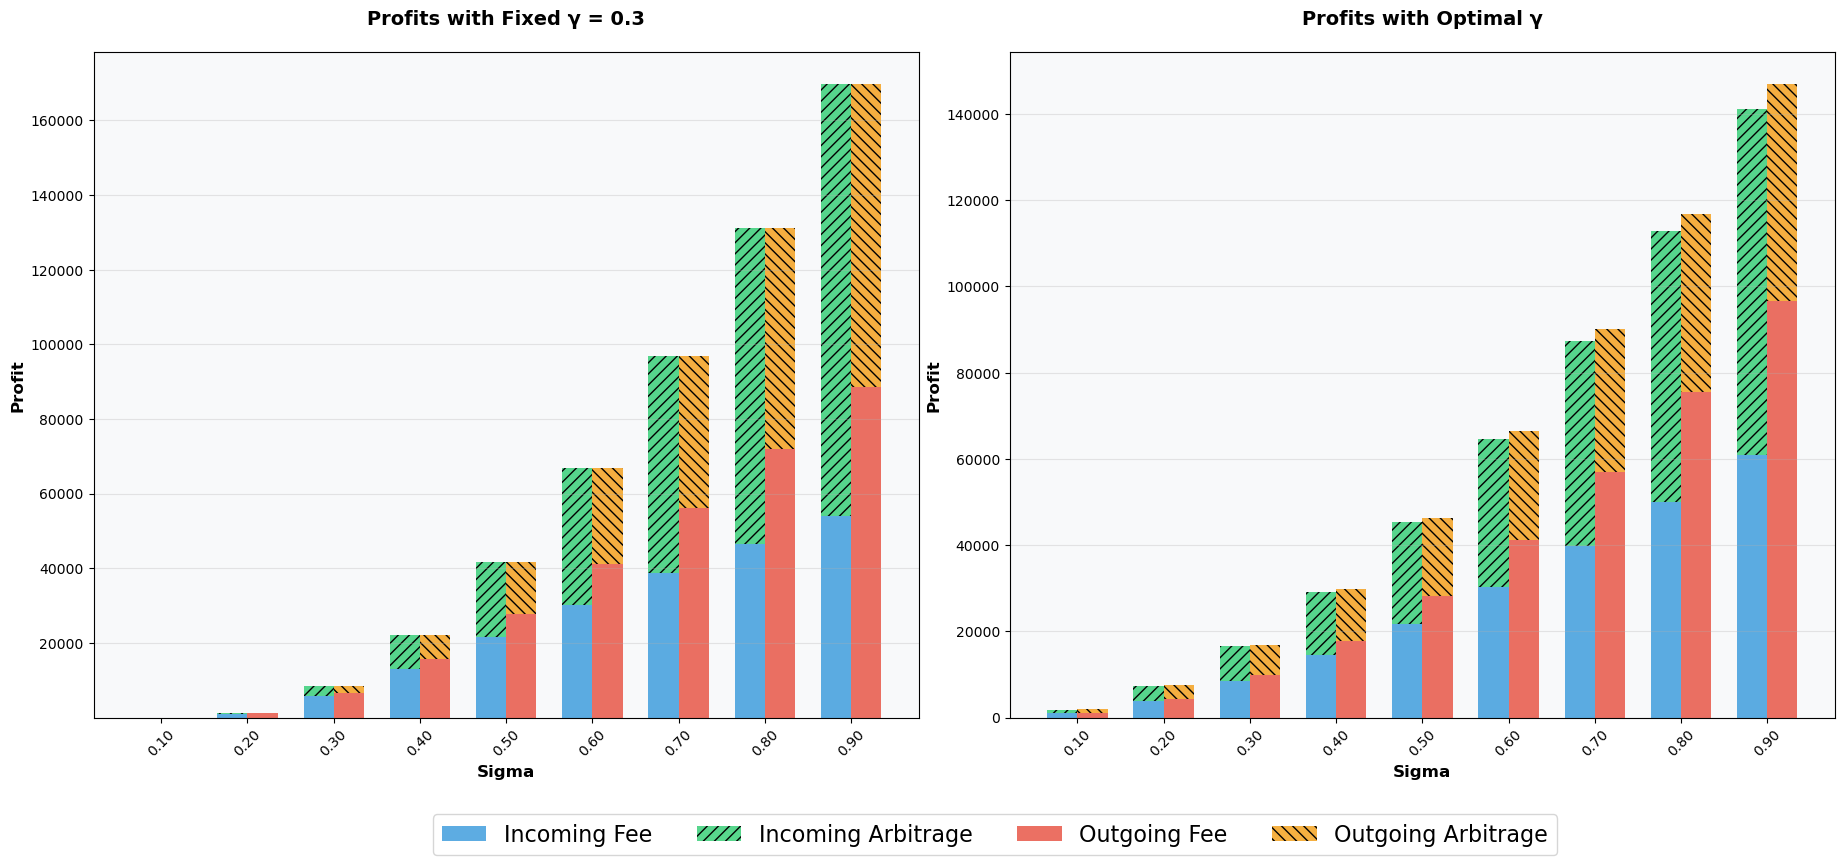

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set the style
sns.set_palette("husl")

# Create figure with 1x2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Group data by sigma and calculate means for both scenarios
grouped_fixed = data.groupby('sigma').agg({
    'incoming_fee': 'mean',
    'arbitrage_incoming': 'mean',
    'outgoing_fee': 'mean',
    'arbitrage_outgoing': 'mean'
}).reset_index()

grouped_opt = data.groupby('sigma').agg({
    'opt_incoming_fee': 'mean',
    'opt_arbitrage_incoming': 'mean',
    'opt_outgoing_fee': 'mean',
    'opt_arbitrage_outgoing': 'mean'
}).reset_index()

# Get unique sigma values
sigma_values = sorted(data['sigma'].unique())
n_groups = len(sigma_values)
x = np.arange(n_groups)
width = 0.35

# Function to create stacked bar plot
def create_stacked_bars(ax, grouped_data, incoming_fee_col, incoming_arb_col, 
                       outgoing_fee_col, outgoing_arb_col, title):
    # Create the grouped stacked bars
    incoming_fees = grouped_data[incoming_fee_col].values
    incoming_arbitrage = grouped_data[incoming_arb_col].values
    outgoing_fees = grouped_data[outgoing_fee_col].values
    outgoing_arbitrage = grouped_data[outgoing_arb_col].values

    # Plot incoming bars (stacked)
    bars1_fee = ax.bar(x - width/2, incoming_fees, width, 
                      label='Incoming Fee', color='#3498db', alpha=0.8)
    bars1_arb = ax.bar(x - width/2, incoming_arbitrage, width, 
                      bottom=incoming_fees, label='Incoming Arbitrage', 
                      color='#2ecc71', alpha=0.8, hatch='///')

    # Plot outgoing bars (stacked)
    bars2_fee = ax.bar(x + width/2, outgoing_fees, width, 
                      label='Outgoing Fee', color='#e74c3c', alpha=0.8)
    bars2_arb = ax.bar(x + width/2, outgoing_arbitrage, width, 
                      bottom=outgoing_fees, label='Outgoing Arbitrage', 
                      color='#f39c12', alpha=0.8, hatch='\\\\\\')

    # Customize the plot
    ax.set_xlabel('Sigma', fontsize=12, fontweight='bold')
    ax.set_ylabel('Profit', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels([f'{s:.2f}' for s in sigma_values], rotation=45)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_facecolor('#f8f9fa')
    return ax

# Create first plot (Fixed γ = 0.3)
ax1 = create_stacked_bars(
    ax1, grouped_fixed,
    'incoming_fee', 'arbitrage_incoming',
    'outgoing_fee', 'arbitrage_outgoing',
    'Profits with Fixed γ = 0.3'
)

# Create second plot (Optimal γ)
ax2 = create_stacked_bars(
    ax2, grouped_opt,
    'opt_incoming_fee', 'opt_arbitrage_incoming',
    'opt_outgoing_fee', 'opt_arbitrage_outgoing',
    'Profits with Optimal γ'
)

# Add legend to the right of the second subplot
handles, labels = ax2.get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(0.5, -0.05), loc='center', fontsize=16, ncol=4)

# Adjust layout to prevent overlap
plt.tight_layout()

# Add some space on the right for the legend
plt.subplots_adjust(right=0.92)

plt.show()

In [ ]:
w=0.1
L = 1e6
pv = 2e6

y0 = (1-w) * pv
x0 = (L/((1-w)*pv)**(1-w))**(1/w)
p0 = (w/(1-w)) * y0 / x0
L = L


print(y0, x0, p0, L)
print(x0 * p0 + y0)

1800000.0 5041.357015064823 39.67185807360012 1000000.0


In [28]:
1800000.0 / 5041.357015064823

357.04672266240107